In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = pd.read_csv("../../../datasets/agriculture_dataset_with_target.csv")
data.sample(5)

feature_columns = [
    'Soil_Moisture',
    'Humidity',
    'Ambient_Temperature',
]

target_column = 'Plant_Health_Status'

required_columns = feature_columns + [target_column]

missing_columns = [col for col in required_columns if col not in data.columns]

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data[required_columns].dtypes)

print("\nMissing values per required column:")
print(data[required_columns].isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Dataset shape: (2000, 12)

Column names:
['Record_ID', 'Timestamp', 'Soil_Moisture', 'Soil_Temperature', 'Soil_pH', 'Humidity', 'Ambient_Temperature', 'Solar_Radiation', 'Wind_Speed', 'NDVI_Index', '5G_Latency_ms', 'Plant_Health_Status']

Data types:
Soil_Moisture          float64
Humidity               float64
Ambient_Temperature    float64
Plant_Health_Status        str
dtype: object

Missing values per required column:
Soil_Moisture          0
Humidity               0
Ambient_Temperature    0
Plant_Health_Status    0
dtype: int64

Duplicate rows: 0


In [5]:
dataset = data[required_columns].copy()
dataset = dataset.dropna()

print("\nShape after dropping missing values:", dataset.shape)

dataset.sample(5)


Shape after dropping missing values: (2000, 4)


,Soil_Moisture,Humidity,Ambient_Temperature,Plant_Health_Status
1171,44.25,87.64,36.39,Moderate Stress
1251,24.26,89.43,30.84,High Stress
343,22.35,83.59,26.69,Healthy
136,25.75,56.68,24.91,Healthy
1842,22.58,34.37,22.35,High Stress



Target class distribution:
Plant_Health_Status
High Stress        688
Healthy            679
Moderate Stress    633
Name: count, dtype: int64


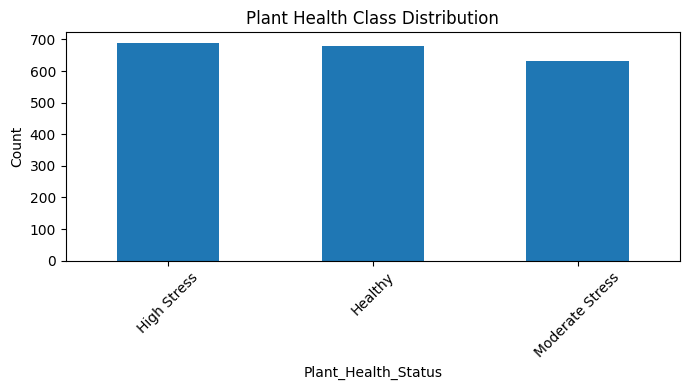

In [6]:
print("\nTarget class distribution:")
print(dataset[target_column].value_counts())

dataset[target_column].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title("Plant Health Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
x = dataset[feature_columns]
y = dataset[target_column]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.3125


In [8]:
print("Train set report:")
train_predictions = model.predict(x_train)
print(classification_report(y_train, train_predictions))

print("Test set report:")
test_predictions = model.predict(x_test)
print(classification_report(y_test, test_predictions))

Train set report:
                 precision    recall  f1-score   support

        Healthy       1.00      1.00      1.00       543
    High Stress       1.00      1.00      1.00       550
Moderate Stress       1.00      1.00      1.00       507

       accuracy                           1.00      1600
      macro avg       1.00      1.00      1.00      1600
   weighted avg       1.00      1.00      1.00      1600

Test set report:
                 precision    recall  f1-score   support

        Healthy       0.30      0.30      0.30       136
    High Stress       0.37      0.36      0.36       138
Moderate Stress       0.27      0.28      0.27       126

       accuracy                           0.31       400
      macro avg       0.31      0.31      0.31       400
   weighted avg       0.31      0.31      0.31       400



<Figure size 600x600 with 0 Axes>

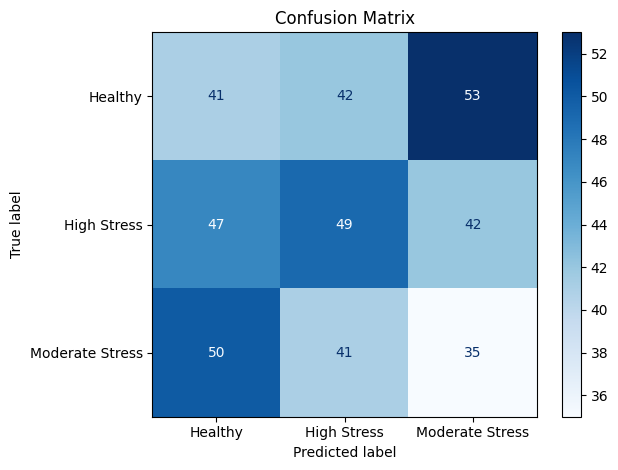

In [9]:
class_labels = sorted(y.unique())

cm = confusion_matrix(y_test, test_predictions, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

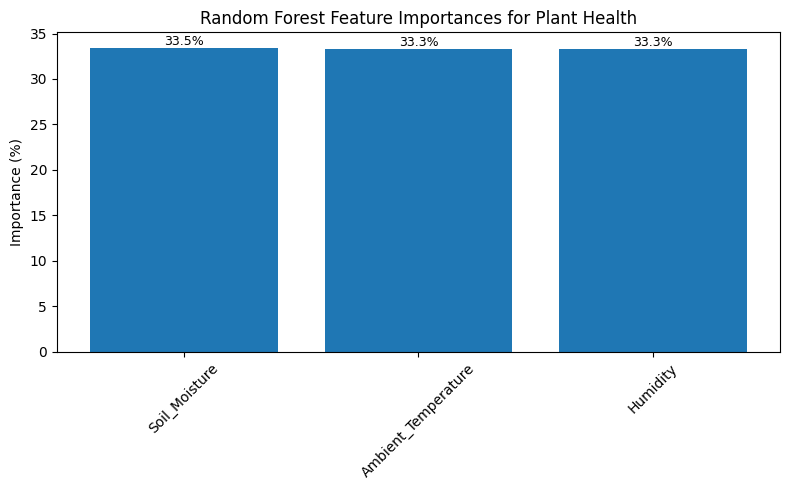

In [10]:
importances = model.feature_importances_
feature_names = x.columns
importances_pct = importances * 100

indices = np.argsort(importances_pct)[::-1]

plt.figure(figsize=(8, 5))
bars = plt.bar(range(len(importances_pct)), importances_pct[indices])

plt.xticks(
    range(len(importances_pct)),
    feature_names[indices],
    rotation=45
)

plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances for Plant Health")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [11]:
print("Dataset Validation Summary")
print("--------------------------")
print(f"Rows used: {len(dataset)}")
print(f"Features used: {feature_columns}")
print(f"Target classes: {sorted(y.unique().tolist())}")
print(f"Missing values removed: {data[required_columns].isnull().any(axis=1).sum()}")
print(f"Duplicate rows in original data: {data.duplicated().sum()}")
print(f"Test accuracy: {accuracy_score(y_test, test_predictions):.4f}")

Dataset Validation Summary
--------------------------
Rows used: 2000
Features used: ['Soil_Moisture', 'Humidity', 'Ambient_Temperature']
Target classes: ['Healthy', 'High Stress', 'Moderate Stress']
Missing values removed: 0
Duplicate rows in original data: 0
Test accuracy: 0.3125


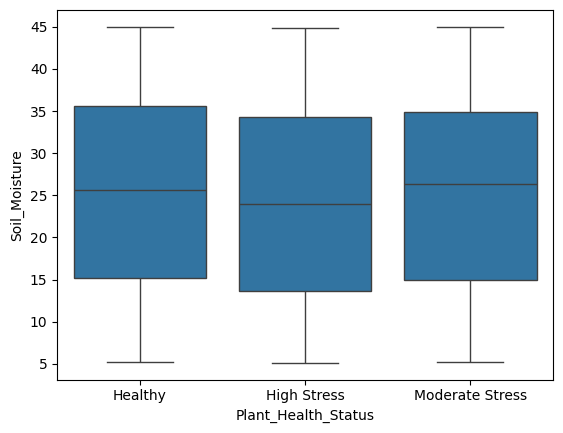

In [16]:
import seaborn as sns

sns.boxplot(x='Plant_Health_Status', y='Soil_Moisture', data=dataset)
plt.show()